In [1]:
import pandas as pd

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape, test.shape)
print(train.columns.tolist())
print(test.columns.tolist())

train.head(5)

(630000, 15) (270000, 14)
['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']
['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [3]:
print(train.isnull().sum())



id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


In [4]:
print(test.isnull().sum())

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64


In [5]:
train.duplicated().sum()

np.int64(0)

In [6]:
print(train['Heart Disease'].value_counts())
print(train['Heart Disease'].value_counts(normalize=True))

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64
Heart Disease
Absence     0.55166
Presence    0.44834
Name: proportion, dtype: float64


In [7]:
print(train.dtypes)

id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object


In [8]:
print(train.describe())

                  id            Age            Sex  Chest pain type  \
count  630000.000000  630000.000000  630000.000000    630000.000000   
mean   314999.500000      54.136706       0.714735         3.312752   
std    181865.479132       8.256301       0.451541         0.851615   
min         0.000000      29.000000       0.000000         1.000000   
25%    157499.750000      48.000000       0.000000         3.000000   
50%    314999.500000      54.000000       1.000000         4.000000   
75%    472499.250000      60.000000       1.000000         4.000000   
max    629999.000000      77.000000       1.000000         4.000000   

                  BP    Cholesterol   FBS over 120    EKG results  \
count  630000.000000  630000.000000  630000.000000  630000.000000   
mean      130.497433     245.011814       0.079987       0.981660   
std        14.975802      33.681581       0.271274       0.998783   
min        94.000000     126.000000       0.000000       0.000000   
25%       120.0

Before model development, the dataset was inspected for common quality issues including missing values, duplicate records, incorrect data types, and outliers. The analysis showed that the dataset was already well-structured and required minimal preprocessing beyond target encoding.

In [9]:
train['target']= train['Heart Disease'].map({ 'Absence':0, 'Presence':1 })

corr= train.drop(columns=['id','Heart Disease']).corr()['target'].sort_values(ascending=False)
print(corr)

target                     1.000000
Thallium                   0.605776
Chest pain type            0.460684
Exercise angina            0.441864
Number of vessels fluro    0.438604
ST depression              0.430641
Slope of ST                0.415050
Sex                        0.342446
EKG results                0.218961
Age                        0.212091
Cholesterol                0.082753
FBS over 120               0.033570
BP                        -0.005181
Max HR                    -0.440985
Name: target, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  roc_auc_score,classification_report, confusion_matrix

x=train.drop(columns=['id','Heart Disease','target'])
y=train['target']

x_train,x_val,y_train,y_val= train_test_split(x,y,test_size=0.2, random_state=42,stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
print("Done")


val_preds=rf.predict(x_val)
val_probs=rf.predict_proba(x_val)[:,1]

print("AUC:", roc_auc_score(y_val,val_probs))
print(classification_report(y_val, val_preds))
print(confusion_matrix(y_val,val_preds))


Done
AUC: 0.9474936131660338
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69509
           1       0.87      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000

[[62487  7022]
 [ 7958 48533]]


In [11]:
from xgboost import XGBClassifier

xgb= XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, eval_metric='auc')
xgb.fit(x_train,y_train)

xgb_probs = xgb.predict_proba(x_val)[:,1]
xgb_preds = xgb.predict(x_val)

print("XGBoost AUC:", roc_auc_score(y_val, xgb_probs))
print(classification_report(y_val,xgb_preds))


XGBoost AUC: 0.9557716958568594
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



In [12]:
import pandas as pd

importances = pd.Series(xgb.feature_importances_, index=x_train.columns).sort_values(ascending=False)
print(importances)

Thallium                   0.650061
Chest pain type            0.122812
Slope of ST                0.058577
Number of vessels fluro    0.045990
Exercise angina            0.040780
Sex                        0.025733
ST depression              0.022034
Max HR                     0.015868
EKG results                0.010157
Age                        0.005081
Cholesterol                0.001471
BP                         0.000902
FBS over 120               0.000533
dtype: float32


In [13]:
xgb_final = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, eval_metric='auc')
xgb_final.fit(x, y)  

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
test_ids = test['id']
x_test = test.drop(columns=['id'])

test_preds = xgb_final.predict_proba(x_test)[:, 1]  

submission = pd.DataFrame({'id': test_ids, 'Heart Disease': test_preds})
submission.to_csv('submission.csv', index=False)

In [ ]:
import joblib
joblib.dump(xgb_final, 'heart_disease_model.pkl')


['heart_disease_xgb.pkl']

In [16]:
print(train[['Age', 'Max HR', 'ST depression']].describe())

                 Age         Max HR  ST depression
count  630000.000000  630000.000000  630000.000000
mean       54.136706     152.816763       0.716028
std         8.256301      19.112927       0.948472
min        29.000000      71.000000       0.000000
25%        48.000000     142.000000       0.000000
50%        54.000000     157.000000       0.100000
75%        60.000000     166.000000       1.400000
max        77.000000     202.000000       6.200000


In [17]:
for col in ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']:
    print(col, train[col].unique())

Sex [1 0]
Chest pain type [4 1 2 3]
FBS over 120 [0 1]
EKG results [0 2 1]
Exercise angina [1 0]
Slope of ST [2 1 3]
Number of vessels fluro [2 0 3 1]
Thallium [7 3 6]


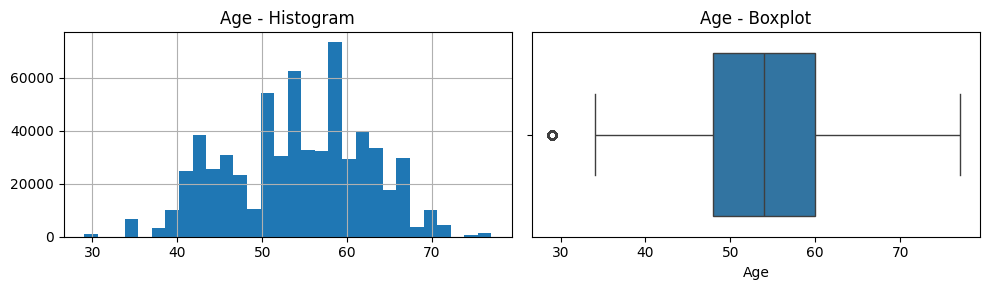

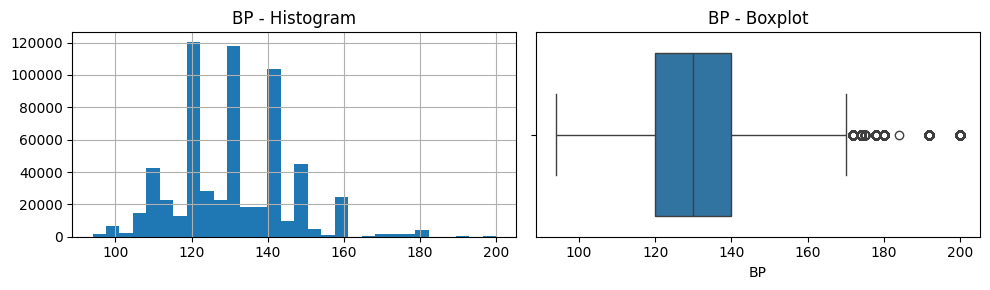

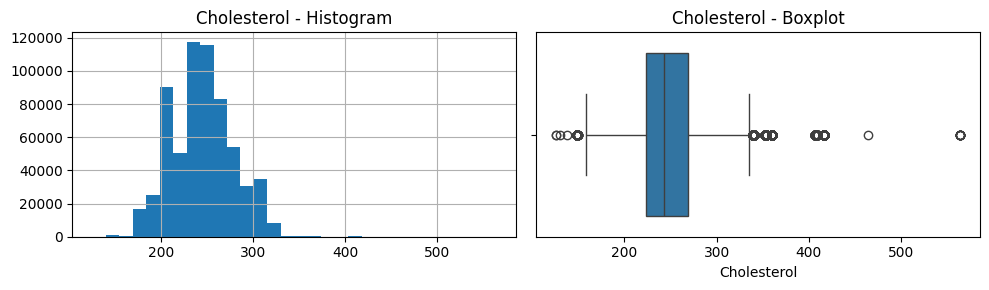

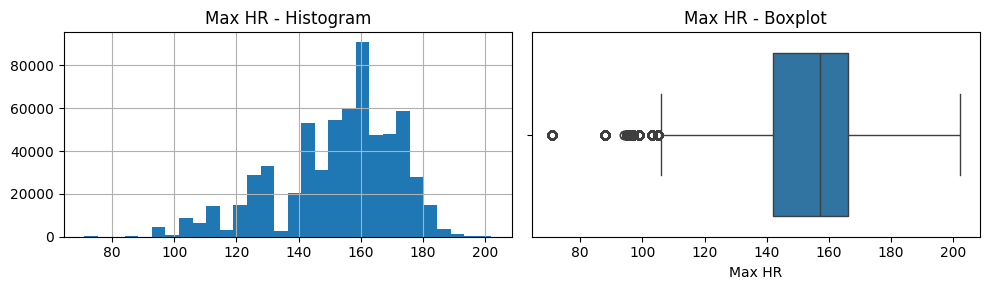

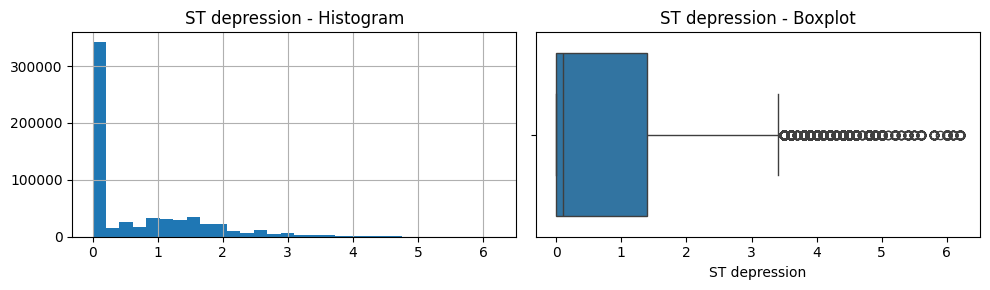

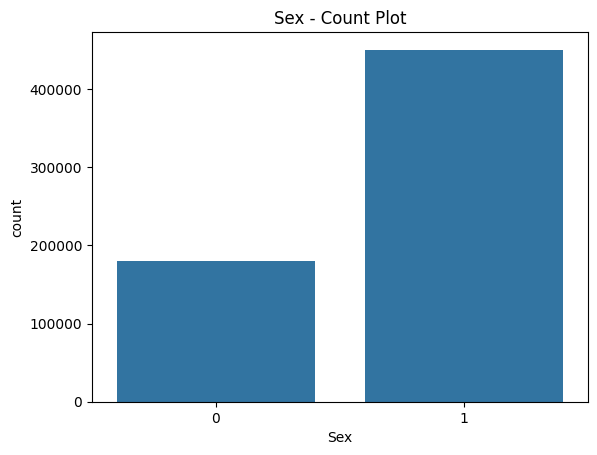

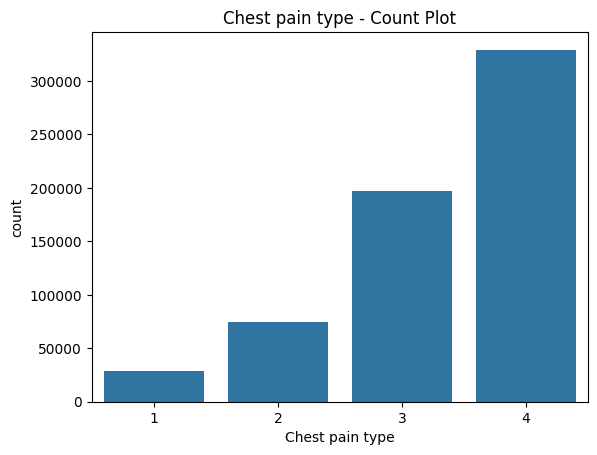

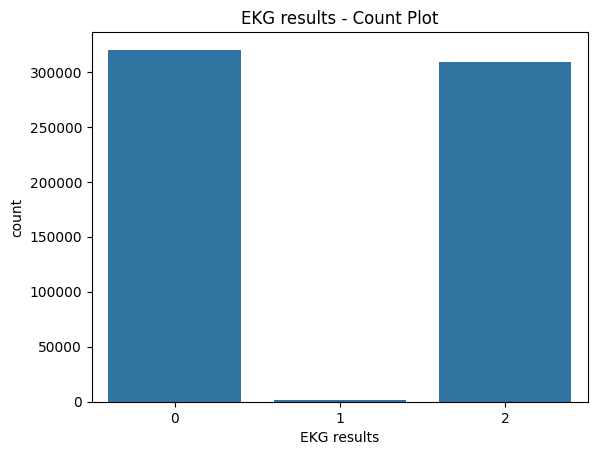

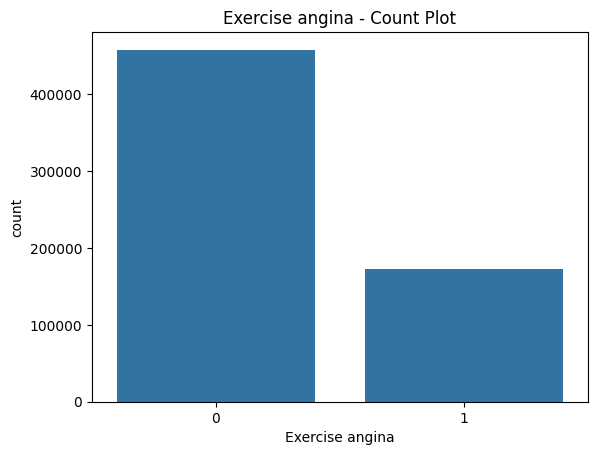

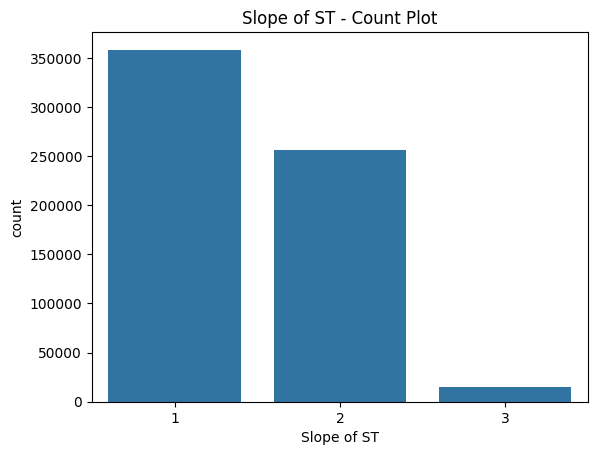

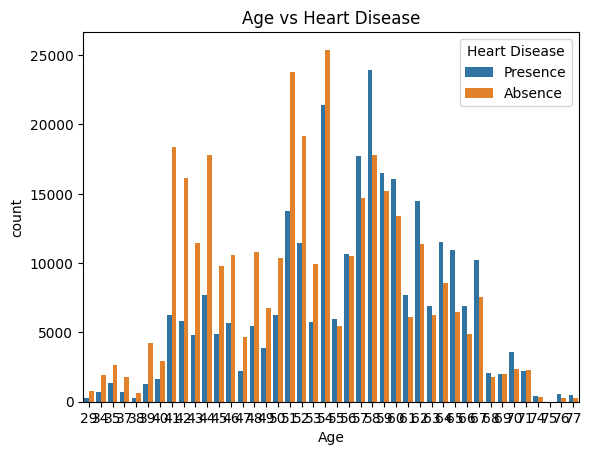

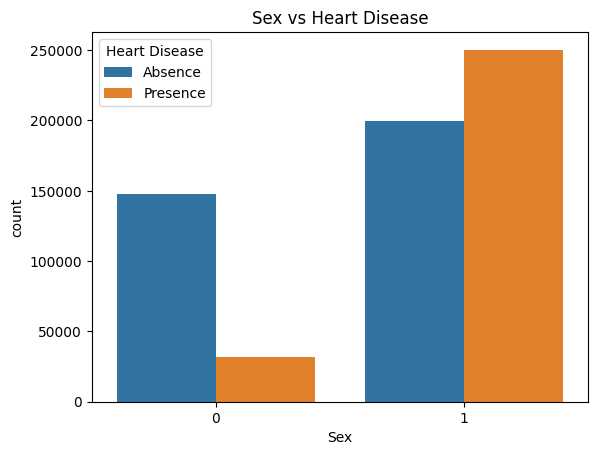

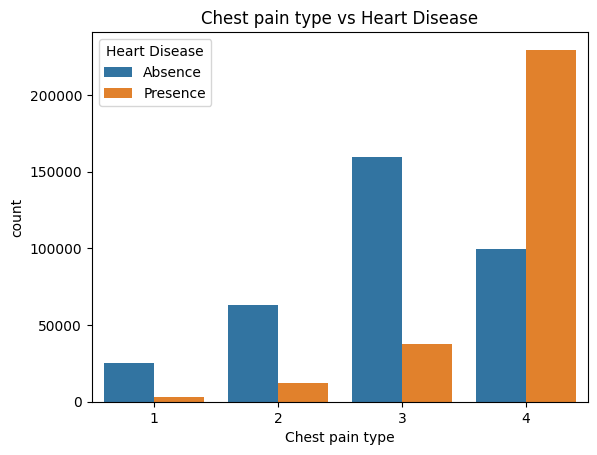

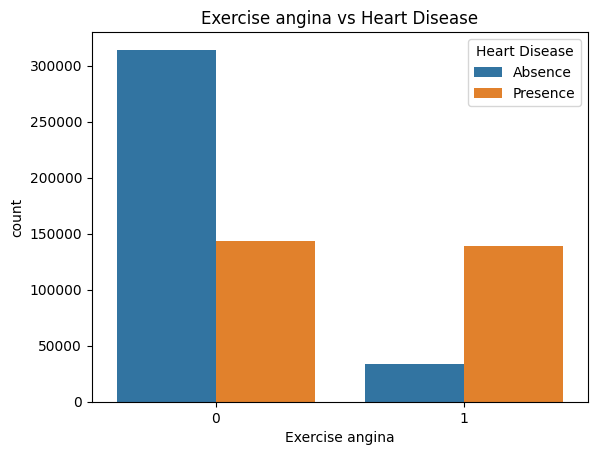

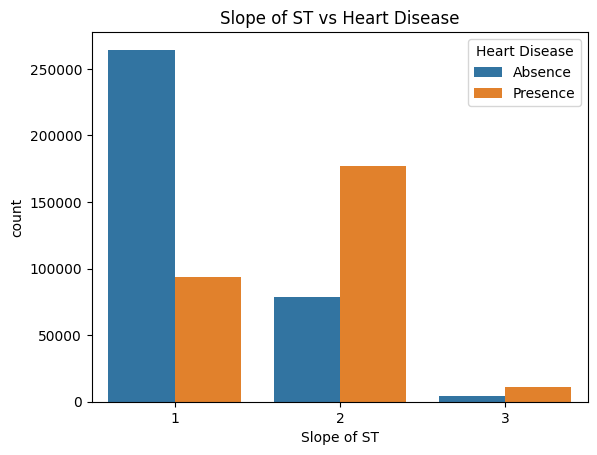

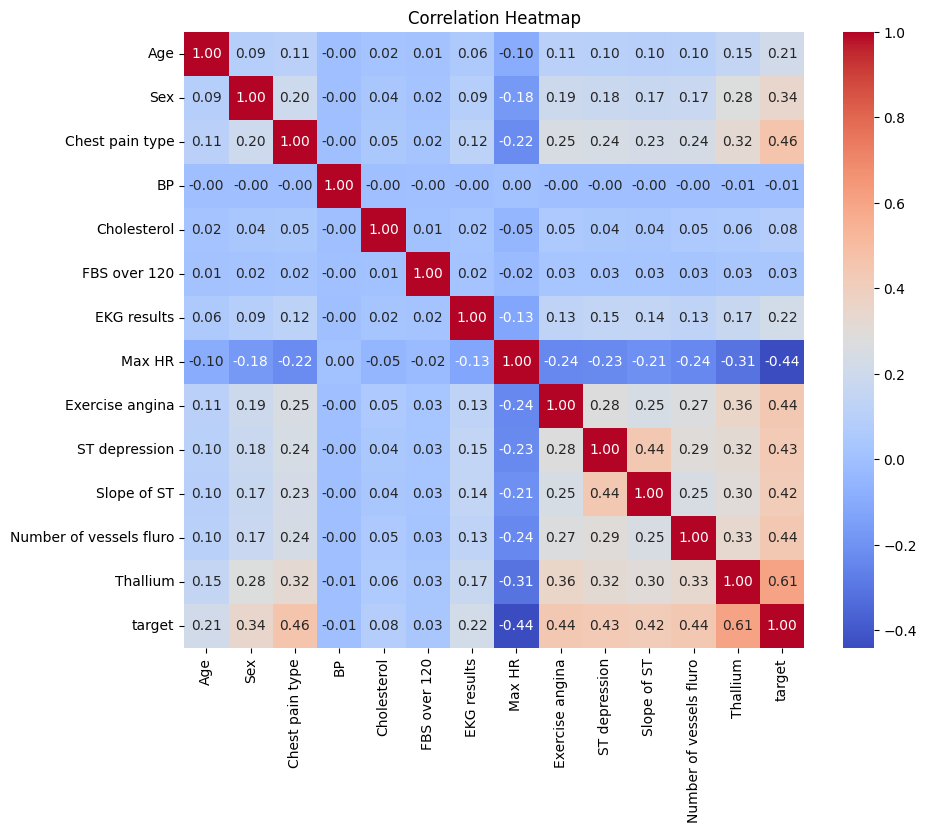

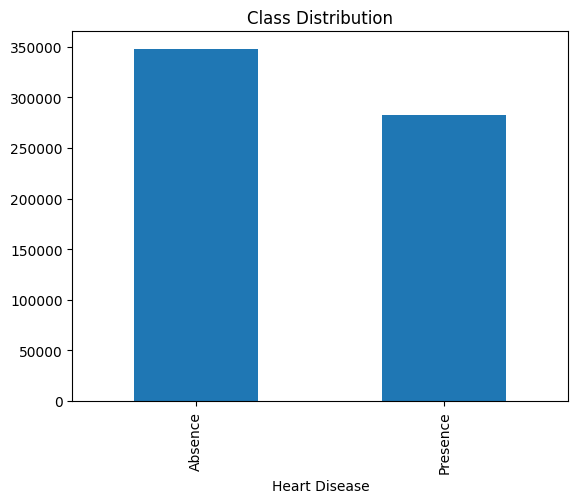

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate: histograms + boxplots for key numeric features
numeric_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    train[col].hist(ax=axes[0], bins=30)
    axes[0].set_title(f'{col} - Histogram')
    sns.boxplot(x=train[col], ax=axes[1])
    axes[1].set_title(f'{col} - Boxplot')
    plt.tight_layout()
    plt.show()

# Categorical count plots
cat_cols = ['Sex', 'Chest pain type', 'EKG results', 'Exercise angina', 'Slope of ST']
for col in cat_cols:
    sns.countplot(x=train[col])
    plt.title(f'{col} - Count Plot')
    plt.show()

# Bivariate: each key feature vs target
for col in ['Age', 'Sex', 'Chest pain type', 'Exercise angina', 'Slope of ST']:
    sns.countplot(data=train, x=col, hue='Heart Disease')
    plt.title(f'{col} vs Heart Disease')
    plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(train.drop(columns=['id', 'Heart Disease']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Class balance
train['Heart Disease'].value_counts().plot(kind='bar', title='Class Distribution')
plt.show()

In [19]:
for col in ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = train[(train[col] < lower) | (train[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(train)*100:.2f}%), bounds [{lower:.2f}, {upper:.2f}]")

Age: 1048 outliers (0.17%), bounds [30.00, 78.00]
BP: 9011 outliers (1.43%), bounds [90.00, 170.00]
Cholesterol: 2194 outliers (0.35%), bounds [154.00, 338.00]
Max HR: 14246 outliers (2.26%), bounds [106.00, 202.00]
ST depression: 9971 outliers (1.58%), bounds [-2.10, 3.50]
